In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

Creating the directory structure to save Graphs and Output for Each Evaluator

In [4]:
output_data_path = os.path.join("output", "combined")
os.makedirs(output_data_path, exist_ok=True)

Reading the Evaluation data by all Pathologist

In [5]:
evaluator_ids = ['evaluator1', 'evaluator2', 'evaluator4', 'evaluator5']
correct_answers_eval_data = []
wrong_answer_eval_data = []
for evaluator_id in evaluator_ids:
    correct_answer_eval_data_path = f"output/{evaluator_id}/pathopen_correct_answer_eval_data.pkl"
    eval_data = pd.read_pickle(correct_answer_eval_data_path)
    correct_answers_eval_data.append(eval_data)

    wrong_answer_eval_data_path = f"output/{evaluator_id}/pathopen_wrong_answer_eval_data.pkl"
    eval_data = pd.read_pickle(wrong_answer_eval_data_path)
    wrong_answer_eval_data.append(eval_data)

Combining all the dataframes into one combined dataframe

In [6]:
correct_answers_eval_data_combined = correct_answers_eval_data[0] + correct_answers_eval_data[1] + correct_answers_eval_data[2] + correct_answers_eval_data[3]
correct_answers_eval_data_combined

Total  Level 2  Level 1  Level 0  \
Open-Ended  Knowledge Interpretation    366      344       15        3   
            Visual Grounding            366      338       19        5   
MCQ         Knowledge Interpretation    184      176        3        4   
            Visual Grounding            184      168       10        5   
Close-Ended Visual Grounding            184      178        3        3   

                                      Level -1  
Open-Ended  Knowledge Interpretation         4  
            Visual Grounding                 4  
MCQ         Knowledge Interpretation         1  
            Visual Grounding                 1  
Close-Ended Visual Grounding                 0

In [7]:
wrong_answers_eval_data_combined = wrong_answer_eval_data[0] + wrong_answer_eval_data[1] + wrong_answer_eval_data[2] + wrong_answer_eval_data[3]
wrong_answers_eval_data_combined

Total  Level 2  Level 1  Level 0  Level -1
Open-Ended Error Proximity     280       56      114      104         6
           Visual Grounding    280       55       99      120         6
MCQ        Error Proximity     736      124      209      399         4
           Visual Grounding    736      127      150      454         5

#### Correct Answers

Open-Ended Correct Answers Graph

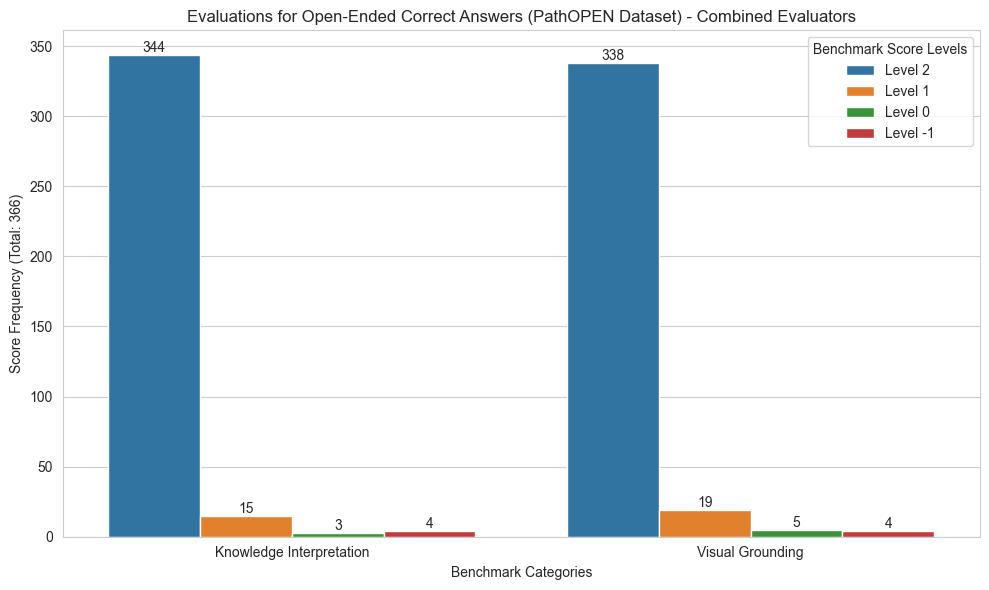

In [17]:
temp_data = correct_answers_eval_data_combined.drop(columns=['Total']).loc['Open-Ended'].transpose().reset_index()
temp_data = temp_data.melt(id_vars='index', var_name='Column Names', value_name='Values')

sns.set_style("whitegrid")
plt.figure(figsize=(10, 6))
ax = sns.barplot(data=temp_data, x='Column Names', y='Values', hue='index')

for container in ax.containers:
    ax.bar_label(container)
plt.title(f'Evaluations for Open-Ended Correct Answers (PathOPEN Dataset) - Combined Evaluators')
plt.xlabel('Benchmark Categories')
plt.ylabel(f'Score Frequency (Total: {correct_answers_eval_data_combined.loc["Open-Ended"]["Total"].iloc[0]})')
plt.legend(title='Benchmark Score Levels')
plt.tight_layout()
plt.savefig(f'{output_data_path}/pathopen_open_ended_correct_answers.png')
plt.show()


MCQ Correct Answers Graph

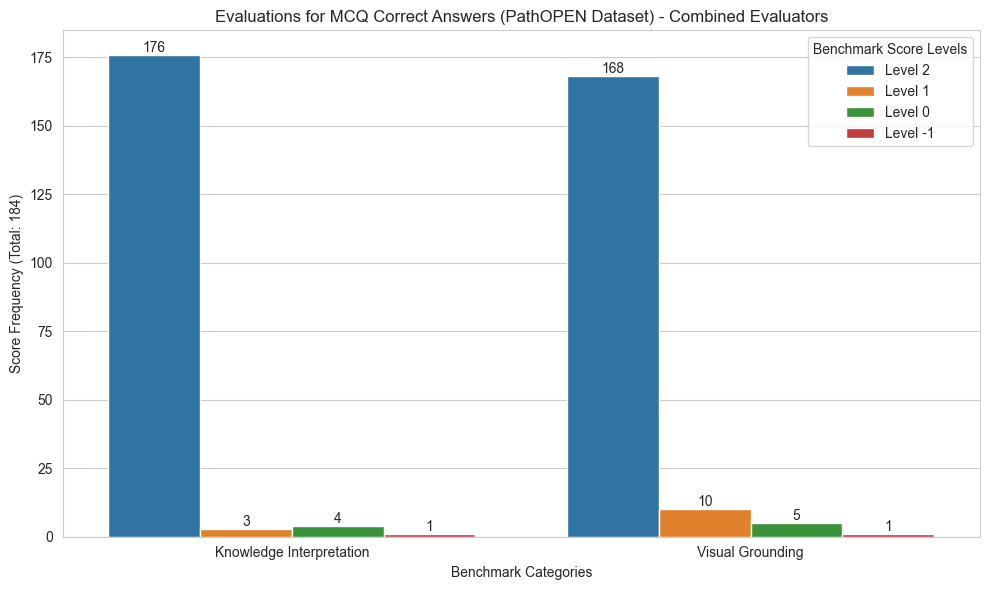

In [20]:
temp_data = correct_answers_eval_data_combined.drop(columns=['Total']).loc['MCQ'].transpose().reset_index()
temp_data = temp_data.melt(id_vars='index', var_name='Column Names', value_name='Values')

sns.set_style("whitegrid")
plt.figure(figsize=(10, 6))
ax = sns.barplot(data=temp_data, x='Column Names', y='Values', hue='index')

for container in ax.containers:
    ax.bar_label(container)

plt.title(f'Evaluations for MCQ Correct Answers (PathOPEN Dataset) - Combined Evaluators')

plt.xlabel('Benchmark Categories')
plt.ylabel(f'Score Frequency (Total: {correct_answers_eval_data_combined.loc["MCQ"]["Total"].iloc[0]})')
plt.legend(title='Benchmark Score Levels')
plt.tight_layout()
plt.savefig(f'{output_data_path}/pathopen_mcq_correct_answers.png')
plt.show()

Close-Ended Correct Answers Graph

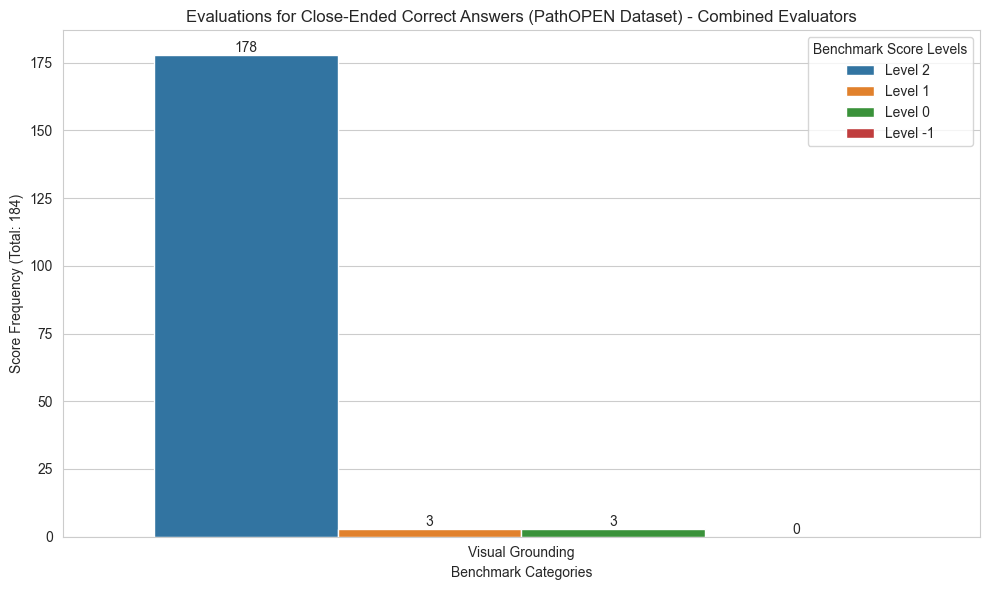

In [21]:
temp_data = correct_answers_eval_data_combined.drop(columns=['Total']).loc['Close-Ended'].transpose().reset_index()
temp_data = temp_data.melt(id_vars='index', var_name='Column Names', value_name='Values')

sns.set_style("whitegrid")
plt.figure(figsize=(10, 6))
ax = sns.barplot(data=temp_data, x='Column Names', y='Values', hue='index')

for container in ax.containers:
    ax.bar_label(container)
    
plt.title(f'Evaluations for Close-Ended Correct Answers (PathOPEN Dataset) - Combined Evaluators')
plt.xlabel('Benchmark Categories')
plt.ylabel(f'Score Frequency (Total: {correct_answers_eval_data_combined.loc["Close-Ended"]["Total"].iloc[0]})')
plt.legend(title='Benchmark Score Levels')
plt.tight_layout()
plt.savefig(f'{output_data_path}/pathopen_close_ended_correct_answers.png')
plt.show()

#### Wrong Answer

Open-Ended Wrong Answers Graph

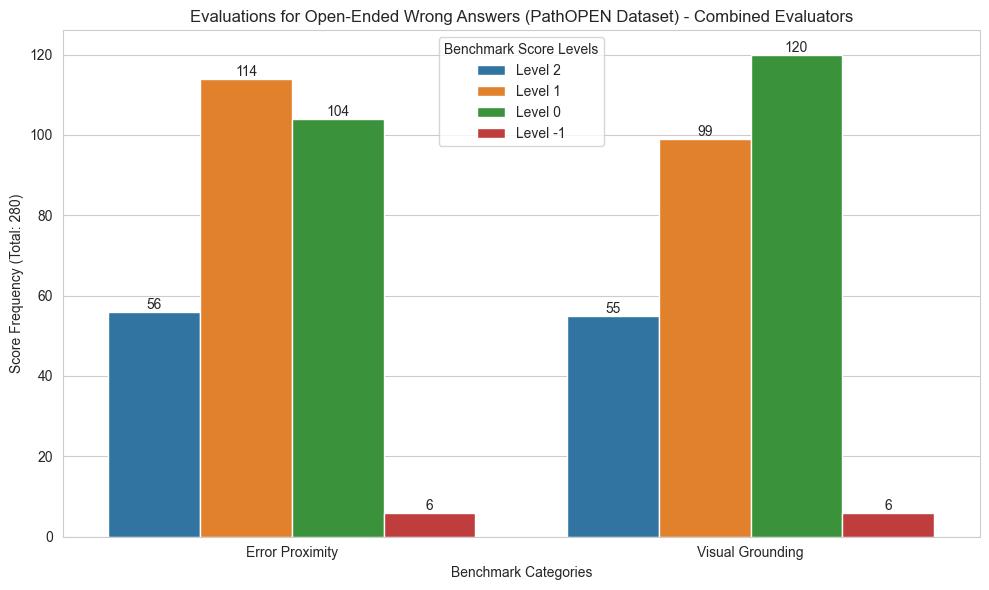

In [22]:
temp_data = wrong_answers_eval_data_combined.drop(columns=['Total']).loc['Open-Ended'].transpose().reset_index()
temp_data = temp_data.melt(id_vars='index', var_name='Column Names', value_name='Values')

sns.set_style("whitegrid")
plt.figure(figsize=(10, 6))
ax = sns.barplot(data=temp_data, x='Column Names', y='Values', hue='index')

for container in ax.containers:
    ax.bar_label(container)
    
plt.title(f'Evaluations for Open-Ended Wrong Answers (PathOPEN Dataset) - Combined Evaluators')
plt.xlabel('Benchmark Categories')
plt.ylabel(f'Score Frequency (Total: {wrong_answers_eval_data_combined.loc["Open-Ended"]["Total"].iloc[0]})')
plt.legend(title='Benchmark Score Levels')
plt.tight_layout()
plt.savefig(f'{output_data_path}/pathopen_open_ended_wrong_answers.png')
plt.show()

MCQ Wrong Answers Graph

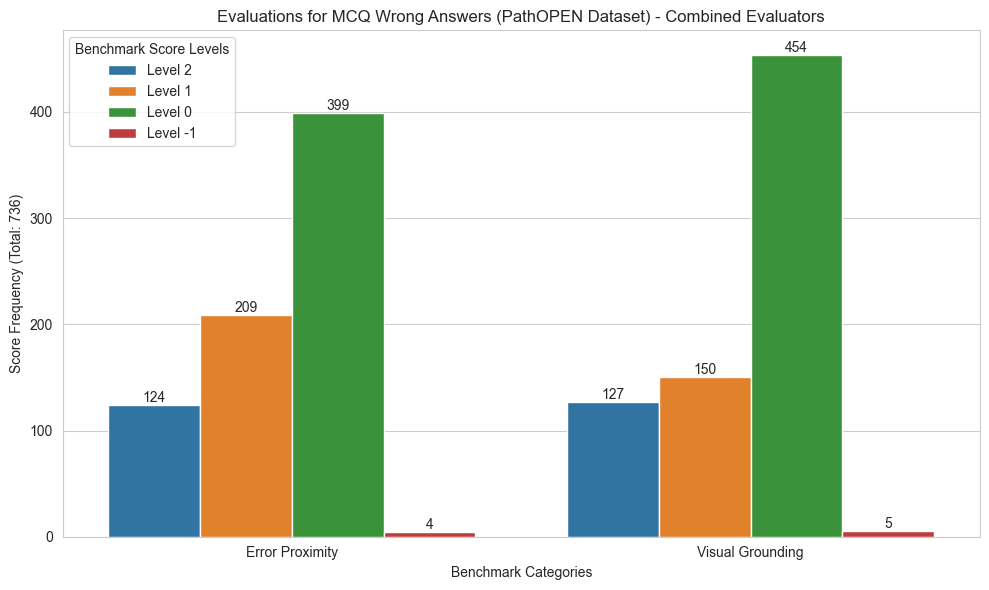

In [23]:
temp_data = wrong_answers_eval_data_combined.drop(columns=['Total']).loc['MCQ'].transpose().reset_index()
temp_data = temp_data.melt(id_vars='index', var_name='Column Names', value_name='Values')

sns.set_style("whitegrid")
plt.figure(figsize=(10, 6))
ax = sns.barplot(data=temp_data, x='Column Names', y='Values', hue='index')

for container in ax.containers:
    ax.bar_label(container)

plt.title(f'Evaluations for MCQ Wrong Answers (PathOPEN Dataset) - Combined Evaluators')
plt.xlabel('Benchmark Categories')
plt.ylabel(f'Score Frequency (Total: {wrong_answers_eval_data_combined.loc["MCQ"]["Total"].iloc[0]})')
plt.legend(title='Benchmark Score Levels')
plt.tight_layout()
plt.savefig(f'{output_data_path}/pathopen_mcq_wrong_answers.png')
plt.show()